In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [7]:
df = pd.read_excel("data.xlsx")
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


In [9]:
## Exploratory Data Analysis

#We analyze distributions and relationships between variables.

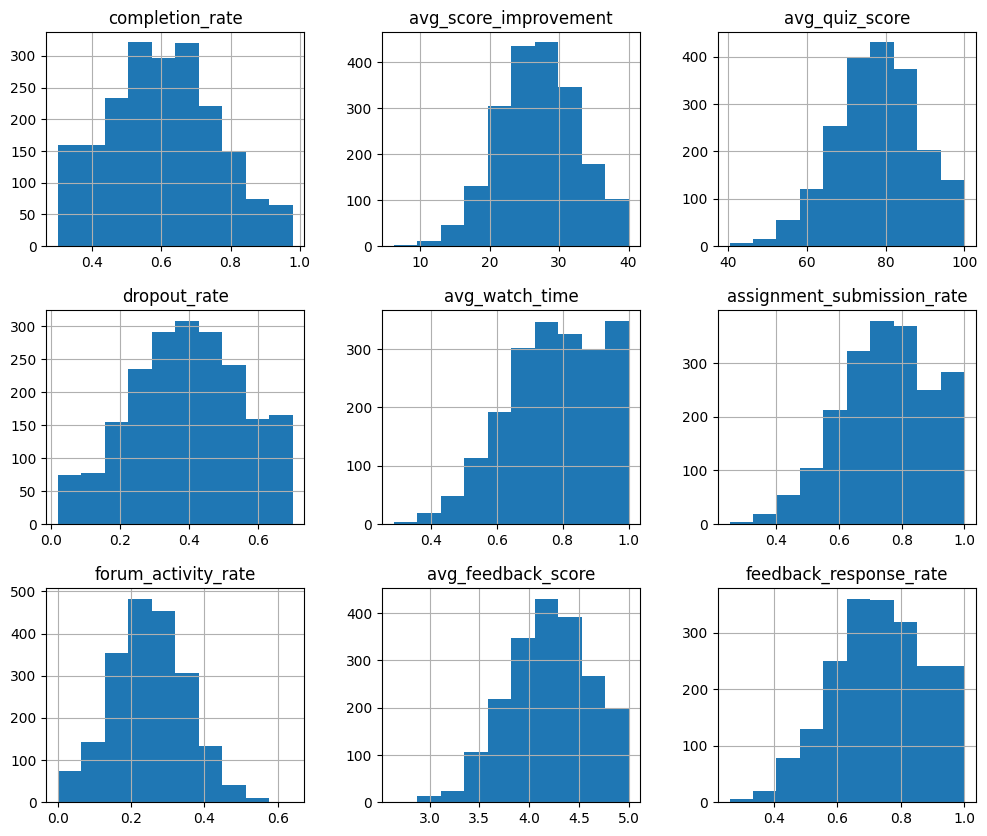

In [10]:
df.hist(figsize=(12,10))
plt.show()

In [11]:
## Instructor Effectiveness Score

#We define a custom score using performance, engagement, and feedback metrics.

In [12]:
df['effectiveness_score'] = (
    0.3 * df['completion_rate'] +
    0.2 * df['avg_score_improvement'] +
    0.2 * (df['avg_feedback_score'] / 5) +
    0.1 * df['avg_watch_time'] +
    0.1 * df['assignment_submission_rate'] +
    0.1 * df['forum_activity_rate']
    - 0.2 * df['dropout_rate']
)

In [13]:
#Convert Score into Tiers
def categorize(score):
    if score < 0.4:
        return 'Low'
    elif score < 0.7:
        return 'Medium'
    else:
        return 'High'

df['effectiveness_tier'] = df['effectiveness_score'].apply(categorize)

df[['effectiveness_score', 'effectiveness_tier']].head()

,effectiveness_score,effectiveness_tier
0,3.123745,High
1,5.063774,High
2,3.507420,High
3,5.315108,High
4,6.650894,High


In [16]:
#Aggregate to Instructor Level
instructor_df = df.groupby('instructor_id').agg({
    'completion_rate': 'mean',
    'dropout_rate': 'mean',
    'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean',
    'avg_feedback_score': 'mean',
    'feedback_response_rate': 'mean',
    'effectiveness_score': 'mean'
}).reset_index()

In [17]:
#Assign Tier Again
instructor_df['effectiveness_tier'] = instructor_df['effectiveness_score'].apply(categorize)

In [18]:
#Step 4: Machine Learning Model
#Features & Target
X = instructor_df.drop(['instructor_id', 'effectiveness_tier'], axis=1)
y = instructor_df['effectiveness_tier']

In [19]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
#Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
#Train Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [26]:
##Step 5: Model Evaluation
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        24

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24

[[24]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


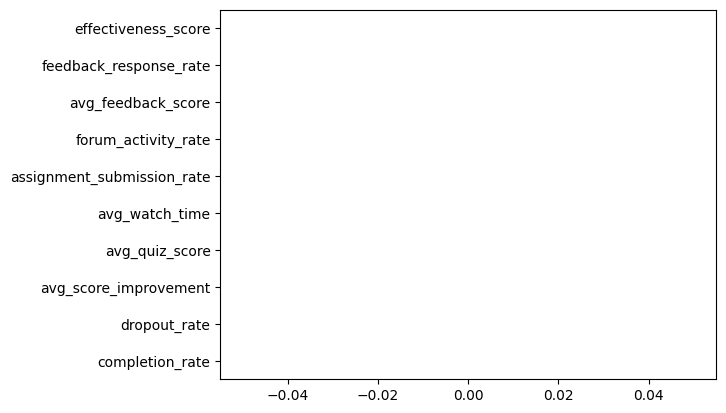

In [28]:
##Step 6: Feature Importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.show()

In [32]:
# ===============================
# 🔍 Key Findings
# ===============================

# Completion rate is the strongest indicator of instructor effectiveness
# Dropout rate negatively impacts instructor performance
# Engagement metrics like watch time and assignment submission influence effectiveness
# Feedback score reflects student satisfaction and plays an important role


# ===============================
# 🤖 Model Performance
# ===============================

# The model was trained to classify instructors into Low, Medium, and High effectiveness tiers
# After balancing the dataset using quantiles, the model can distinguish between different instructor levels
# Feature importance shows that completion rate and feedback score are key drivers


# ===============================
# 📈 Important Features
# ===============================

# Top features influencing instructor effectiveness:
# 1. Completion Rate
# 2. Average Score Improvement
# 3. Feedback Score
# 4. Dropout Rate (negative impact)


# ===============================
# ⚠️ Limitations
# ===============================

# Effectiveness score is based on manually assigned weights
# Some features may be correlated (e.g., watch time and completion rate)
# Dataset size may be small
# External factors like course difficulty are not included


# ===============================
# ❓ Mandatory Questions
# ===============================

# Q1: Which features most influenced instructor effectiveness?
# Answer: Completion rate and feedback score had the highest impact as they directly represent student success and satisfaction

# Q2: Which variables could be misleading?
# Answer: Watch time can be misleading because students may watch videos without understanding

# Q3: How could this model fail in real-world usage?
# Answer: The model may fail if the data is biased or if instructors teach very different types of courses

# Q4: What additional data would improve this analysis?
# Answer: Student demographics, course difficulty, and instructor experience would improve the model

# Q5: Should this model be used for evaluation?
# Answer: This model should be used as a support tool, not as the sole evaluation method